# Scikit-learn MPI adaptation from UL HPC Tutorial

Parallel machine learning with scikit-learn

Adapted from: https://ipyparallel.readthedocs.io/en/latest/mpi.html

ipyparallel is a Python package and collection of CLI scripts for controlling clusters for Jupyter.

Interactive Parallel Computing with IPython.

ipyparallel contains the following CLI scripts:

    ipcluster - start/stop a cluster
    ipcontroller - start a scheduler
    ipengine - start an engine

As ipython is interactive and parallel, each MPI process (chosen for this case) is running, consuming processing, waiting for a command to be executed interactively. It is different from traditional compiled MPI where a process ends as soon as the program ends. In the case of ipython the process needs to be explicitly terminated, otherwise it will be waiting. If we choose to run using, for example, 4 MPI processes, then there will be 4 processes running continuously and waiting for commands.

## Running on a single node without Slurm

Check MPI

In [1]:
! mpiexec --version

mpiexec (OpenRTE) 4.0.2

Report bugs to http://www.open-mpi.org/community/help/


<br>

From: https://ipython.readthedocs.io/en/stable/development/config.html

A profile is a directory containing configuration and runtime files.

The command

    $ ipython profile create

generate the default configuration files. You will have a default `ipython_config.py` in your IPython directory (~/.ipython/) under `profile_default`.

The command

    $ ipython profile create <name>

adds a directory called `profile_<name>` to the IPython directory. Then you can load this profile by adding --profile=<name> to your command line options.

The command
    
    $ 


Create blank Python config file to store cluster configurations

In [2]:
%%bash
ipython profile create --parallel --profile=mpi

<br>
ipcluster only works in one terminal, open a terminal and run it, it can be a JupyterLab terminal, it will be active in the terminal, if you need to close or stop just close the terminal window:

    $ ipcluster start -n 4 --profile=mpi

[This does the following:](https://ipython.org/ipython-doc/3/parallel/parallel_process.html)
* Starts the IPython controller on current host.
* Uses **mpiexec** to start 4 engines.
* The engines will keep running continuously until they are stopped.

Ipyparallel engines running:

![](img/ul01.png)

![](img/ul02.png)

<br>Ipyparallel

In [3]:
import ipyparallel as ipp

<br>Start a semi-synchronous client to an IPython parallel cluster

In [4]:
c = ipp.Client(profile='mpi')

<br>Show the engines ready to do work

In [50]:
c.ids

[0, 1, 2, 3]

<br>Show the dict of all our results, keyed by msg_id (no results yet)

In [51]:
c.results

defaultdict(dict, {})

<br>Use all engines

In [52]:
view = c[:]

<br>activate(targets='all', suffix='')

Create a DirectView and register it with IPython magics

Defines the magics %px, %autopx, %pxresult, %%px

e.g. rc.activate(targets=0, suffix='0') will give you the magics %px0, %pxresult0, etc. for running magics just on engine 0


In [53]:
view.activate()

<br>Create a file on disk

In [54]:
%%writefile hi.py
import numpy as np
a=np.arange(16,dtype='float')

Overwriting hi.py


<br>run(filename, targets=None, block=None)

Execute contents of filename on my engine(s)

This simply reads the contents of the file and calls execute

In [55]:
view.run('hi.py', block=True).get()

[, , , ]

In [56]:
with view.sync_imports():
    import numpy as np

importing numpy on engine(s)


<br>scatter(key, seq, dist='b', flatten=False, targets=None, block=None, track=None)

Partition a Python sequence and send the partitions to a set of engines

In [57]:
view.scatter('a',np.arange(16,dtype='float')).get()

[None, None, None, None]

In [58]:
view['a']

[array([0., 1., 2., 3.]),
 array([4., 5., 6., 7.]),
 array([ 8.,  9., 10., 11.]),
 array([12., 13., 14., 15.])]

In [59]:
b = %px np.sum(a)

In [60]:
b.get()

[Out[0:6]: 6.0,
 Out[1:6]: 22.0,
 Out[2:6]: 38.0,
 Out[3:6]: 54.0]

In [61]:
b = %px tot = np.sum(a)

In [62]:
b.get()

[, , , ]

In [63]:
view['tot']

[6.0, 22.0, 38.0, 54.0]

<br>execute(code, silent=True, targets=None, block=None)

Executes code on targets in blocking or nonblocking manner

In [64]:
view.execute('print("oi")', block=True)

<AsyncResult: execute:finished>

In [65]:
view.results

defaultdict(dict, {})

## Recognize hand-written digits

See https://ulhpc-tutorials.readthedocs.io/en/latest/python/advanced/scikit-learn/

In [2]:
import argparse
import logging
import os
import sys
# import matplotlib as mpl
# mpl.use('Agg')
# import matplotlib.pyplot as plt
# from matplotlib.colors import Normalize
from joblib import Parallel, parallel_backend
from joblib import register_parallel_backend
from joblib import delayed
from joblib import cpu_count
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from ipyparallel import Client
from ipyparallel.joblib import IPythonParallelBackend
import numpy as np
import pandas as pd
import datetime
from sklearn.model_selection import GridSearchCV

In [68]:
cpu_count()

12

In [3]:
#prepare the engines
c = Client(profile="mpi")

In [4]:
bview = c.load_balanced_view()

In [5]:
register_parallel_backend('ipyparallel',
                          lambda : IPythonParallelBackend(view=bview))

In [6]:
#Get data
digits = load_digits()

In [7]:
#prepare it for the custom function
X_train, X_test, y_train, y_test = train_test_split(digits.data,
                                                    digits.target,
                                                    test_size=0.3)

In [8]:
#some parameters to test in parallel
param_space = {
    'C': np.logspace(-6, 6, 20),
    'gamma': np.logspace(-6,1,20)
}

In [9]:
svc_rbf = SVC(kernel='rbf', shrinking=False)

In [10]:
search = GridSearchCV(svc_rbf,
                      param_space,
                      return_train_score = True,
                      n_jobs = len(c))

In [11]:
with parallel_backend('ipyparallel'):
    search.fit(X_train, y_train)

OS load

![](img/ul03.png)

In [78]:
results = search.cv_results_
results = pd.DataFrame(results)
results.to_csv('scores_rbf_digits.csv')

In [12]:
%%bash
head -3 scores_rbf_digits.csv

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.13373384475708008,0.008670249633707773,0.026911449432373048,0.0019429822036279053,1e-06,1e-06,"{'C': 1e-06, 'gamma': 1e-06}",0.10317460317460317,0.10714285714285714,0.10756972111553785,0.10756972111553785,0.10358565737051793,0.10580851198381078,0.001993125709125585,150,0.10646766169154229,0.1054726368159204,0.10536779324055666,0.10536779324055666,0.10636182902584493,0.10580754280288418,0.0004983796824442156
1,0.12189664840698242,0.004704758571591133,0.0257051944732666,0.0006720285436430215,1e-06,2.335721469090121e-06,"{'C': 1e-06, 'gamma': 2.335721469090121e-06}",0.10317460317460317,0.10714285714285714,0.10756972111553785,0.1075697211155

In [13]:
scores = search.cv_results_['mean_test_score'].reshape(len(param_space['C']),len(param_space['gamma']))

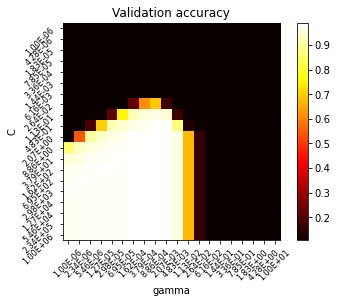

In [15]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
plt.figure()
#plt.subplots_adjust(left=.2, right=0.95, bottom=0.15, top=0.95)
plt.imshow(scores, interpolation='nearest', cmap=plt.cm.hot)
plt.xlabel('gamma')
plt.ylabel('C')
plt.colorbar()
plt.xticks(np.arange(len(param_space['gamma'])), map(lambda x : "%.2E"%(x),param_space['gamma']), fontsize=8, rotation=45)
plt.yticks(np.arange(len(param_space['C'])), map(lambda x : "%.2E"%(x),param_space['C']), fontsize=8, rotation=45)
plt.title('Validation accuracy')
plt.show()

<br>

---

# MPI

    ipython profile create mpi --parallel
    ipcontroller --ip="*" --profile=mpi
    mpiexec -n 4 ipengine --profile=mpi

In [ ]:
%%bash
ipython profile create --profile=mpi --parallel

Execute on Terminal:

    $ ipcontroller --ip="*" --profile=mpi
    $ mpiexec -n 4 ipengine --profile=mpi

## ipcontroller

![](img/ul04.png)

ipcontroller processes provide an interface for working with a set of engines. At a general level, the controller is a collection of processes to which IPython engines and clients can connect. The controller is composed of a Hub and a collection of Schedulers. These Schedulers are typically run in separate processes but on the same machine as the Hub, but can be run anywhere from local threads or on remote machines. (https://ipython.org/ipython-doc/)

![](img/ul05.png)

## ipengine

![](img/ul06.png)

The ipengine is a Python instance that takes Python commands over a network connection

![](img/ul07.png)

## Architeture

Source: https://ipython.org/ipython-doc

![](img/ipa.png)

The IPython architecture consists of:
* Engine (ipengine)
* Controller (ipcontroller)
    * Hub
    * Schedulers

In [12]:
import ipyparallel as ipp
c = ipp.Client(profile='mpi')
c.ids

[0, 1, 2, 3]

In [9]:
%%px
from mpi4py import MPI
comm = MPI.COMM_WORLD
print (comm.rank, comm.size)

[stdout:0] 2 4
[stdout:1] 0 4
[stdout:2] 3 4
[stdout:3] 1 4


<br>Shuts down the engine and bring down the central controller process as well

In [13]:
c.shutdown(hub=True)

![](img/ul08.png)

<br>
Starting again and running the same code above

In [16]:
import argparse, logging, os, sys, datetime, pandas as pd, numpy as np
from joblib import Parallel, parallel_backend, register_parallel_backend, delayed, cpu_count
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from ipyparallel import Client
from ipyparallel.joblib import IPythonParallelBackend

In [17]:
c = Client(profile="mpi")
c.ids

[0, 1, 2, 3]

In [18]:
bview = c.load_balanced_view()
register_parallel_backend('ipyparallel',
                          lambda : IPythonParallelBackend(view=bview))

In [19]:
digits = load_digits()

In [20]:
X_train, X_test, y_train, y_test = train_test_split(digits.data,
                                                    digits.target,
                                                    test_size=0.3)

In [21]:
param_space = {
    'C': np.logspace(-6, 6, 20),
    'gamma': np.logspace(-6,1,20)
}

In [22]:
svc_rbf = SVC(kernel='rbf', shrinking=False)

In [23]:
search = GridSearchCV(svc_rbf,
                      param_space,
                      return_train_score = True,
                      n_jobs = len(c))

<br>Part of the code that depends on performance

In [24]:
with parallel_backend('ipyparallel'):
    search.fit(X_train, y_train)

<br>Result

In [25]:
results = pd.DataFrame(search.cv_results_)
scores = search.cv_results_['mean_test_score'].reshape(len(param_space['C']),len(param_space['gamma']))

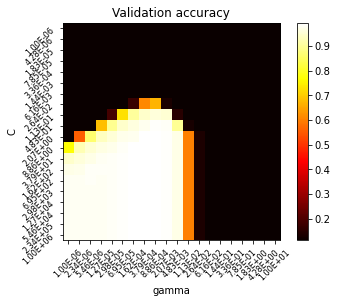

In [26]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
plt.figure()
plt.imshow(scores, interpolation='nearest', cmap=plt.cm.hot)
plt.xlabel('gamma')
plt.ylabel('C')
plt.colorbar()
plt.xticks(np.arange(len(param_space['gamma'])), map(lambda x : "%.2E"%(x),param_space['gamma']), fontsize=8, rotation=45)
plt.yticks(np.arange(len(param_space['C'])), map(lambda x : "%.2E"%(x),param_space['C']), fontsize=8, rotation=45)
plt.title('Validation accuracy')
plt.show()

# References

* https://ipyparallel.readthedocs.io/en/latest/mpi.html
* https://docu.ngsolve.org/latest/i-tutorials/unit-5a.1-mpi/poisson_mpi.html
* https://ipython.readthedocs.io/en/stable/development/config.html
* https://ipython.org/ipython-doc/3/parallel/parallel_process.html
